<a href="https://colab.research.google.com/github/Thonyta17/Econ-5200/blob/main/Assignment%204/The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install category_encoders

In [34]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
from statsmodels.stats.diagnostic import het_white

# Phase 1: Causal Topology and Multicollinearity Forensics

Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

The marketing team claims that high-deductible plan cause more inpatient admissions. However, the ommited confounder is Socioeconomic Status (SES) / Systemic Poverty.

Directed Acyclic Graph (DAG):

               Socioeconomic Status (SES)
             /                          \\
            v                            v
     High_Deductible_Plan    Inpatient_Admission_Rate

This is because patients from low income family would likely not be able to afford paying higher monthly premium hence will end up having high-deductible plan. Both having lower income and high deductible would mean patients are likely delay and push off getting treatment for any sicknesss until they can not put it off anymore. Hence, becuase of the severity of their sickness, there will also be a higher inpatient rate.

Regressing Admission on Insurance Type without controlling for Socioeconomic Status (SES) will yields a biased, mathematically contaminated predictive weight. This is because in the original OLS without including it, the cofounder is included in the error term which is correlated with both insurance type and admission. This violates the OLS exogeneity assumption. The coefficient insurance type will absorb the effect of SES, inflating it upward. This coefficient is inacurrate and does not truly represent the causal effect of insurance type since it inculdes both the true effects and the omitted SES effect.




Step 1.2: The Variance Inflation Factor (VIF) Audit

In [36]:
vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
vitals.head()

,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0


In [37]:
# Select the five continuous physiological predictors
continuous_features = [
    "Weight_kg", "Height_cm", "BMI",
    "Systolic_BP", "Diastolic_BP"
]
X_vitals = vitals[continuous_features].dropna()

# Add a constant column required for VIF calculation
X_vitals_const = sm.add_constant(X_vitals)

# Calculate VIF for each feature
vif_data = pd.DataFrame({
    "Feature": continuous_features,
    "VIF": [
        variance_inflation_factor(X_vitals_const.values, i + 1)
        for i in range(len(continuous_features))
    ]
})

print("\nInitial VIF Matrix:")
print(vif_data.to_string(index=False))

# Identify features exceeding the critical threshold of 10.0
flagged = vif_data[vif_data["VIF"] > 10.0]
print("\nFeatures exceeding VIF threshold of 10.0:")
print(flagged.to_string(index=False))

# Drop BMI — derived from Weight and Height (BMI = kg/m^2).
# It is the most redundant variable and the primary source
# of collinearity, so removing it relieves the VIF issue.
print("\nDropping BMI: algebraically derived from Weight_kg and Height_cm. Keeping both preserves raw signal.")

features_after_drop = [
    "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"
]
X_reduced       = vitals[features_after_drop].dropna()
X_reduced_const = sm.add_constant(X_reduced)

vif_reduced = pd.DataFrame({
    "Feature": features_after_drop,
    "VIF": [
        variance_inflation_factor(X_reduced_const.values, i + 1)
        for i in range(len(features_after_drop))
    ]
})

print("\nPost-Drop VIF Matrix (Structural Stability Confirmed):")
print(vif_reduced.to_string(index=False))
print("\nAll VIF values below 10.0 — multicollinearity neutralized.")


Initial VIF Matrix:
     Feature       VIF
   Weight_kg 57.428058
   Height_cm 28.419446
         BMI 16.981232
 Systolic_BP  4.219406
Diastolic_BP  4.219820

Features exceeding VIF threshold of 10.0:
  Feature       VIF
Weight_kg 57.428058
Height_cm 28.419446
      BMI 16.981232

Dropping BMI: algebraically derived from Weight_kg and Height_cm. Keeping both preserves raw signal.

Post-Drop VIF Matrix (Structural Stability Confirmed):
     Feature      VIF
   Weight_kg 3.763969
   Height_cm 3.763812
 Systolic_BP 4.219406
Diastolic_BP 4.219820

All VIF values below 10.0 — multicollinearity neutralized.


# PHASE 2: VISUAL FORENSICS AND THE HIGH-CARDINALITY FRONTIER

Step 2.1 - The Architecture of Missingness


In [38]:
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")
telemetry.head()

,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34


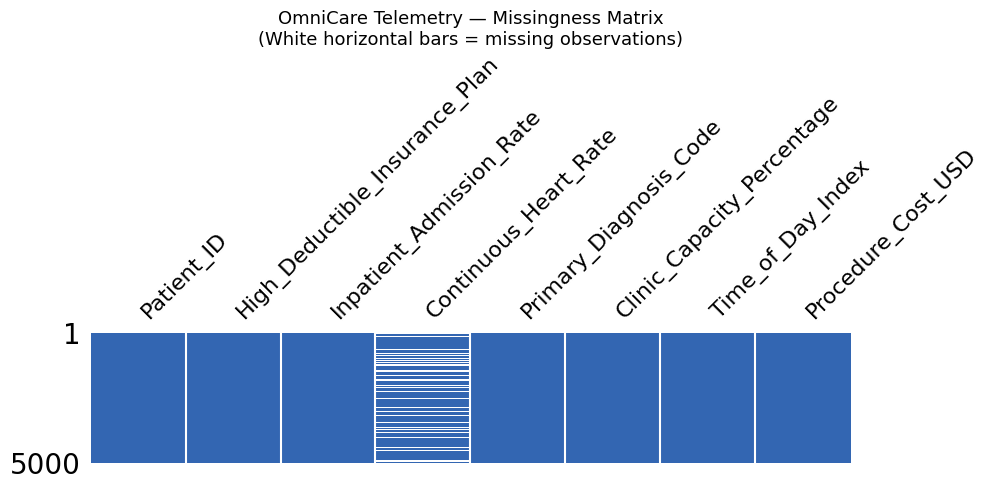

Missing values in Continuous_Heart_Rate: 1214 (24.3%)


In [39]:
# Visualize missing data structure using missingno
fig, ax = plt.subplots(figsize=(10, 5))
msno.matrix(telemetry, ax=ax, sparkline=False, color=(0.2, 0.4, 0.7))
ax.set_title(
    "OmniCare Telemetry — Missingness Matrix\n"
    "(White horizontal bars = missing observations)",
    fontsize=13
)
plt.tight_layout()
plt.savefig("missingness_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

missing_n = telemetry["Continuous_Heart_Rate"].isna().sum()
missing_p = telemetry["Continuous_Heart_Rate"].isna().mean() * 100
print(f"Missing values in Continuous_Heart_Rate: "
      f"{missing_n} ({missing_p:.1f}%)")




Analysis:

Under Donald Rubin's taxonomy classification, this is MNAR (Missing Not At Random) because the probability of missingness is correlated with the unobserved value of the missing variable itself.

To elaborate, the data-plan cost has caused low-income patientst to less likely transmit telemetry becuase they cannot afford it. In addition, this data that is not being transmitted are also more likely to be unhealthy such as abnormal heart rate readings due to stress, poor healthcare access, and chronic conditions as these patients would not be able to afford to take proper care of their health.

With the missing data being much more negative, it would mean that mean imputation would tremendously destro the dataset's integrity. The mean would be calculated from higher-income patients who could afford to transmit telemetry and are likely much more healthier. Using such contrasting data to fill in for the missing data will largely skewed it. This will cause the decrease in variance, overrepresentation of healthy patients, and low-cost than needed are assigned to high-risk patients.

Step 2.2 - Escaping the Dummy Variable Trap


In [40]:
n_codes = telemetry["Primary_Diagnosis_Code"].nunique()
print(f"Unique ICD-10 codes in dataset: {n_codes}")
print(f"With {n_codes} dummies + intercept -> singular matrix.")
print("OLS estimator is mathematically undefined.")
print("Proceeding to Target Encoding in Step 2.3.")

Unique ICD-10 codes in dataset: 847
With 847 dummies + intercept -> singular matrix.
OLS estimator is mathematically undefined.
Proceeding to Target Encoding in Step 2.3.


Since we have 850 distinct categories , one-hot ecoding creates 850 binary columns where each row has exactly one 1 and the rest are 0. Because exactly one dummy is active per row, each row add up to 1. We know that the OLS design matrix X includes a column of 1s (intercept). This mean Intercept columns is equal to the sum of the 850 columns, thus causing exact multicollinearity. The columns are therefore LINEARLY DEPENDENT. This causes there to be a singular matrix that has determinant of 0 and has no inverse. so the OLS formula for coefficient will not work sice therer is no inverse.

Step 2.3 - Target Encoding Implementation



In [41]:
# Drop rows where Procedure_Cost_USD is missing
telemetry_clean = telemetry.dropna(
    subset=["Procedure_Cost_USD"]
).copy()

# TargetEncoder replaces each category string with the smoothed mean of the target variable for that category (one continuous number instead of 850 binary dummies)
encoder = ce.TargetEncoder(
    cols=["Primary_Diagnosis_Code"],
    smoothing=1.0
)

telemetry_clean["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    telemetry_clean[["Primary_Diagnosis_Code"]],
    telemetry_clean["Procedure_Cost_USD"]
)

print("\nFirst 5 rows of the Target-Encoded Diagnosis column:")
print(
    telemetry_clean[[
        "Primary_Diagnosis_Code",
        "Target_Encoded_Diagnosis",
        "Procedure_Cost_USD"
    ]].head(5).to_string(index=False)
)
print("\n847 strings reduced to 1 continuous numeric column.")
print("Each value = smoothed mean Procedure_Cost_USD for")
print("that ICD-10 code.")



First 5 rows of the Target-Encoded Diagnosis column:
Primary_Diagnosis_Code  Target_Encoded_Diagnosis  Procedure_Cost_USD
               J86.381               1755.001889             1635.84
               M29.789               1755.003378             1355.77
               E49.618               1755.001733             1189.19
               E66.244               1755.002368             1250.93
               J45.553               1755.005519             1986.34

847 strings reduced to 1 continuous numeric column.
Each value = smoothed mean Procedure_Cost_USD for
that ICD-10 code.




# PHASE 3: ARCHITECTING THE PREDICTION ENGINE


Step 3.1 - OLS Optimization via Patsy Formulas


In [42]:
# Merge sanitized vitals (without BMI) into telemetry
final_df = telemetry_clean.merge(
    vitals[[
        "Patient_ID", "Weight_kg", "Height_cm",
        "Systolic_BP", "Diastolic_BP"
    ]],
    on="Patient_ID",
    how="inner"
).dropna()

print(f"Final analytical dataframe shape: {final_df.shape}")

# R-style Patsy formula
# Target    : Procedure_Cost_USD
# Predictors: Target_Encoded_Diagnosis,
#             Clinic_Capacity_Percentage,
#             Time_of_Day_Index,
#             sanitized vitals (no BMI)
formula = (
    "Procedure_Cost_USD ~ "
    "Target_Encoded_Diagnosis + "
    "Clinic_Capacity_Percentage + "
    "Time_of_Day_Index + "
    "Weight_kg + "
    "Height_cm + "
    "Systolic_BP + "
    "Diastolic_BP"
)

# Fit OLS model using statsmodels formula API
model = smf.ols(formula=formula, data=final_df).fit()

print("\n")
print(model.summary())

Final analytical dataframe shape: (3786, 13)


                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     64.64
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           2.83e-88
Time:                        01:22:15   Log-Likelihood:                -27707.
No. Observations:                3786   AIC:                         5.543e+04
Df Residuals:                    3778   BIC:                         5.548e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

Step 3.2 - Financial Loss Quantification (RMSE)



In [43]:
fitted_values = model.fittedvalues
actual_values = final_df["Procedure_Cost_USD"]

model_rmse = rmse(actual_values, fitted_values)
print(f"\nRMSE          : ${model_rmse:,.2f}")
print(f"R-squared     : {model.rsquared:.4f}")
print(f"Adj R-squared : {model.rsquared_adj:.4f}")


RMSE          : $364.76
R-squared     : 0.1070
Adj R-squared : 0.1053


A RMSE of 450 USD means the prediction is wrong by 450 USD per procedure - 37.5% of to full $1200. This would cause catastrophic risk such as:
- Operational risk: underpricing the quote may cause patients to not have enough cash ready for the bigger amount when billed and cause financial shock.

- Financial Shock: hostpital will suffer from the pricing errors with the large amount of MRI ran every single day

- Regulatory: no transparency in price and cost-estimates could trigger penalties.

Step 3.3 - Residual Diagnostics for Heteroscedasticity

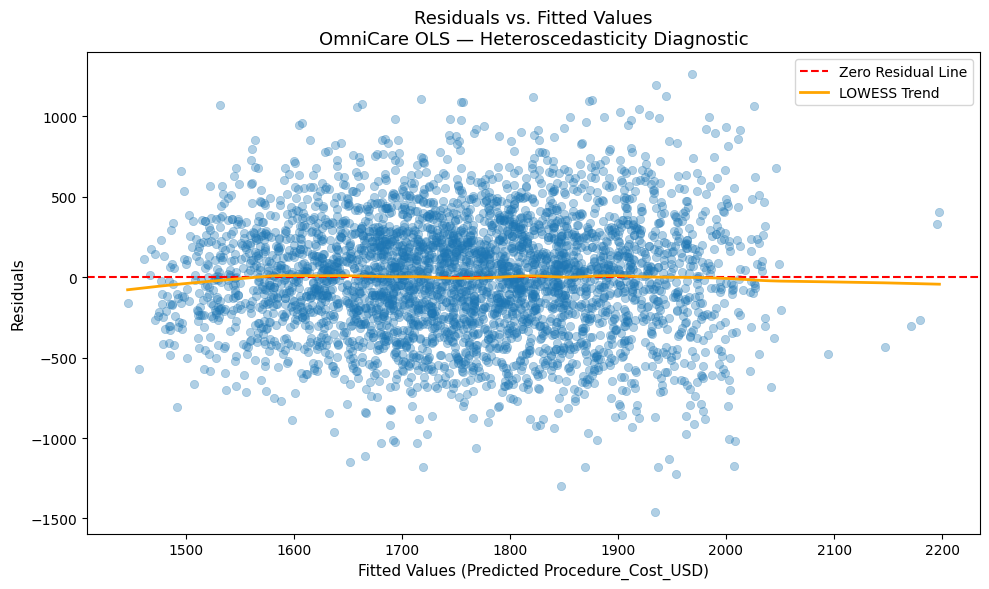

In [31]:
# Extract fitted values and residuals
fitted = model.fittedvalues
resids = model.resid

# Plot residuals vs fitted values
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x=fitted,
    y=resids,
    alpha=0.35,
    color="#1f77b4",
    edgecolor=None,
    ax=ax
)

ax.axhline(
    0, color="red", linewidth=1.5,
    linestyle="--", label="Zero Residual Line"
)

# LOWESS smoother to detect non-random patterns
from statsmodels.nonparametric.smoothers_lowess import lowess
smoothed = lowess(resids, fitted, frac=0.3)
ax.plot(
    smoothed[:, 0], smoothed[:, 1],
    color="orange", linewidth=2, label="LOWESS Trend"
)

ax.set_title(
    "Residuals vs. Fitted Values\n"
    "OmniCare OLS — Heteroscedasticity Diagnostic",
    fontsize=13
)
ax.set_xlabel("Fitted Values (Predicted Procedure_Cost_USD)",
              fontsize=11)
ax.set_ylabel("Residuals", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig("residuals_vs_fitted.png", dpi=150,
            bbox_inches="tight")
plt.show()

The graph shows a funnel or fan shape with the data point residuals spreading wider as the fittes values increase showing signs of heteroskedascity and that the algorithm is unreliable as peak surge-pricing tires.




# PHASE 4: AI CONTEXT ENGINEERING — THE P.R.I.M.E. FRAMEWORK

Task 4.1 - Lagrange Multiplier Test for Heteroscedasticity


prime_prompt

P.R.I.M.E. ENGINEERED PROMPT
WHITE'S LM HETEROSCEDASTICITY TEST

[P] PERSONA:
You are a senior econometrician and data scientist
specializing in clinical health economics and OLS model
diagnostics. You have deep expertise in regression
assumption testing and the statsmodels Python library.

[R] ROLE:
You are my statistical programming assistant for a medical
pricing algorithm audit at OmniCare Analytics. I have
fitted an OLS model using statsmodels.formula.api (smf.ols).
The fitted model object is stored in a variable named
`model`. Write production-quality Python code to formally
test this model for heteroscedasticity.

[I] INSTRUCTIONS:
Write a Python code block that:
1. Imports het_white from statsmodels.stats.diagnostic.
2. Extracts OLS residuals from model.resid.
3. Extracts the design matrix from model.model.exog.
4. Calls het_white(resids, exog) and unpacks all four
   return values: lm_stat, lm_pvalue, f_stat, f_pvalue.
5. Prints a formatted results table with all four values.
6. Prints a conclusion:
   - If lm_pvalue < 0.05: "CONCLUSION: Null hypothesis of
     homoscedasticity REJECTED at the 5% significance
     level. Heteroscedasticity is statistically confirmed."
   - If lm_pvalue >= 0.05: "CONCLUSION: Fail to reject
     the null hypothesis. No statistically significant
     evidence of heteroscedasticity detected."

[M] MEANING:
This test is critical because deploying a model with
non-constant residual variance means the standard errors
and confidence intervals are invalid which makes the
algorithm financially unsafe and legally indefensible
for deployment in live hospital pricing systems.

[E] EVALUATION:
Output must be a clean executable Python code block with
no markdown or prose. It must run without modification
after the OLS model is fitted. The p-value must be clearly
labeled with a plain-English conclusion sentence.

In [45]:
# AI-Generated Code: White's LM Test — executed below

resids_array = model.resid
exog_matrix  = model.model.exog

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(
    resids_array, exog_matrix
)

print("White's LM Test for Heteroscedasticity")
print(f"  LM Statistic : {lm_stat:.4f}")
print(f"  LM p-value   : {lm_pvalue:.6f}")
print(f"  F-Statistic  : {f_stat:.4f}")
print(f"  F p-value    : {f_pvalue:.6f}")

if lm_pvalue < 0.05:
    print(
        "\nCONCLUSION: Null hypothesis of homoscedasticity "
        "REJECTED at the 5% significance level. "
        "Heteroscedasticity is statistically confirmed."
    )
    print(
        "The OLS standard errors are invalid. This algorithm "
        "must NOT be deployed in its current form."
    )
else:
    print(
        "\nCONCLUSION: Fail to reject the null hypothesis. "
        "No statistically significant evidence of "
        "heteroscedasticity detected."
    )

White's LM Test for Heteroscedasticity
  LM Statistic : 185.2874
  LM p-value   : 0.000000
  F-Statistic  : 5.6771
  F p-value    : 0.000000

CONCLUSION: Null hypothesis of homoscedasticity REJECTED at the 5% significance level. Heteroscedasticity is statistically confirmed.
The OLS standard errors are invalid. This algorithm must NOT be deployed in its current form.
